# Chromatin Peak to Trough Analysis and Metrics

Summarize the chromatin peak-to-trough ratios for each gene. There will be a few methods we can try. 

1. First, let's get an idea of what the peak-to-trough ratio values are for all the chromatin cells for all genes.
2. Then, try a few threshold values to get a sense of how we can partition the genes into cell cycling and non-cell cycling gene groups


In [51]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

In [99]:
analysis = PeakToTroughAnalysis()

Created a dictionary of PTR arrays of size: 5402
So, there were 372 genes that did not deconvolve
Created a numpy array of all deconvolved gene PTRs of shape: (5774, 3, 9)
5344 genes have non-nan deconvolution chromatin PTRs


Truncating large PTR outlier values (1 gene). So N=5755


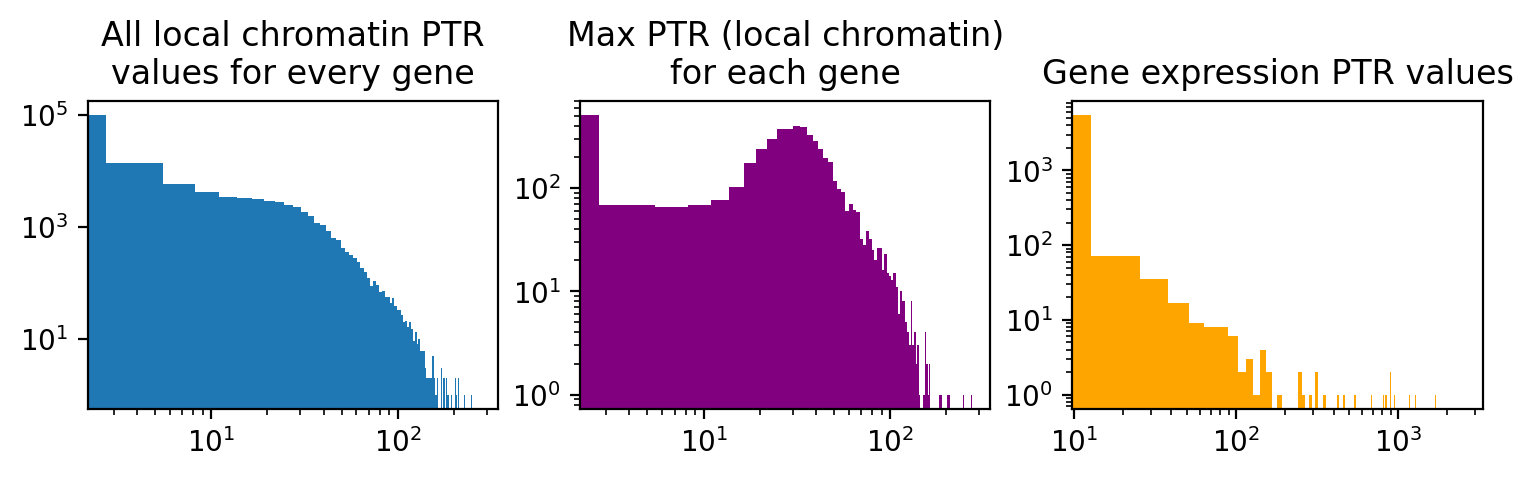

In [285]:
analysis.plot_histograms()

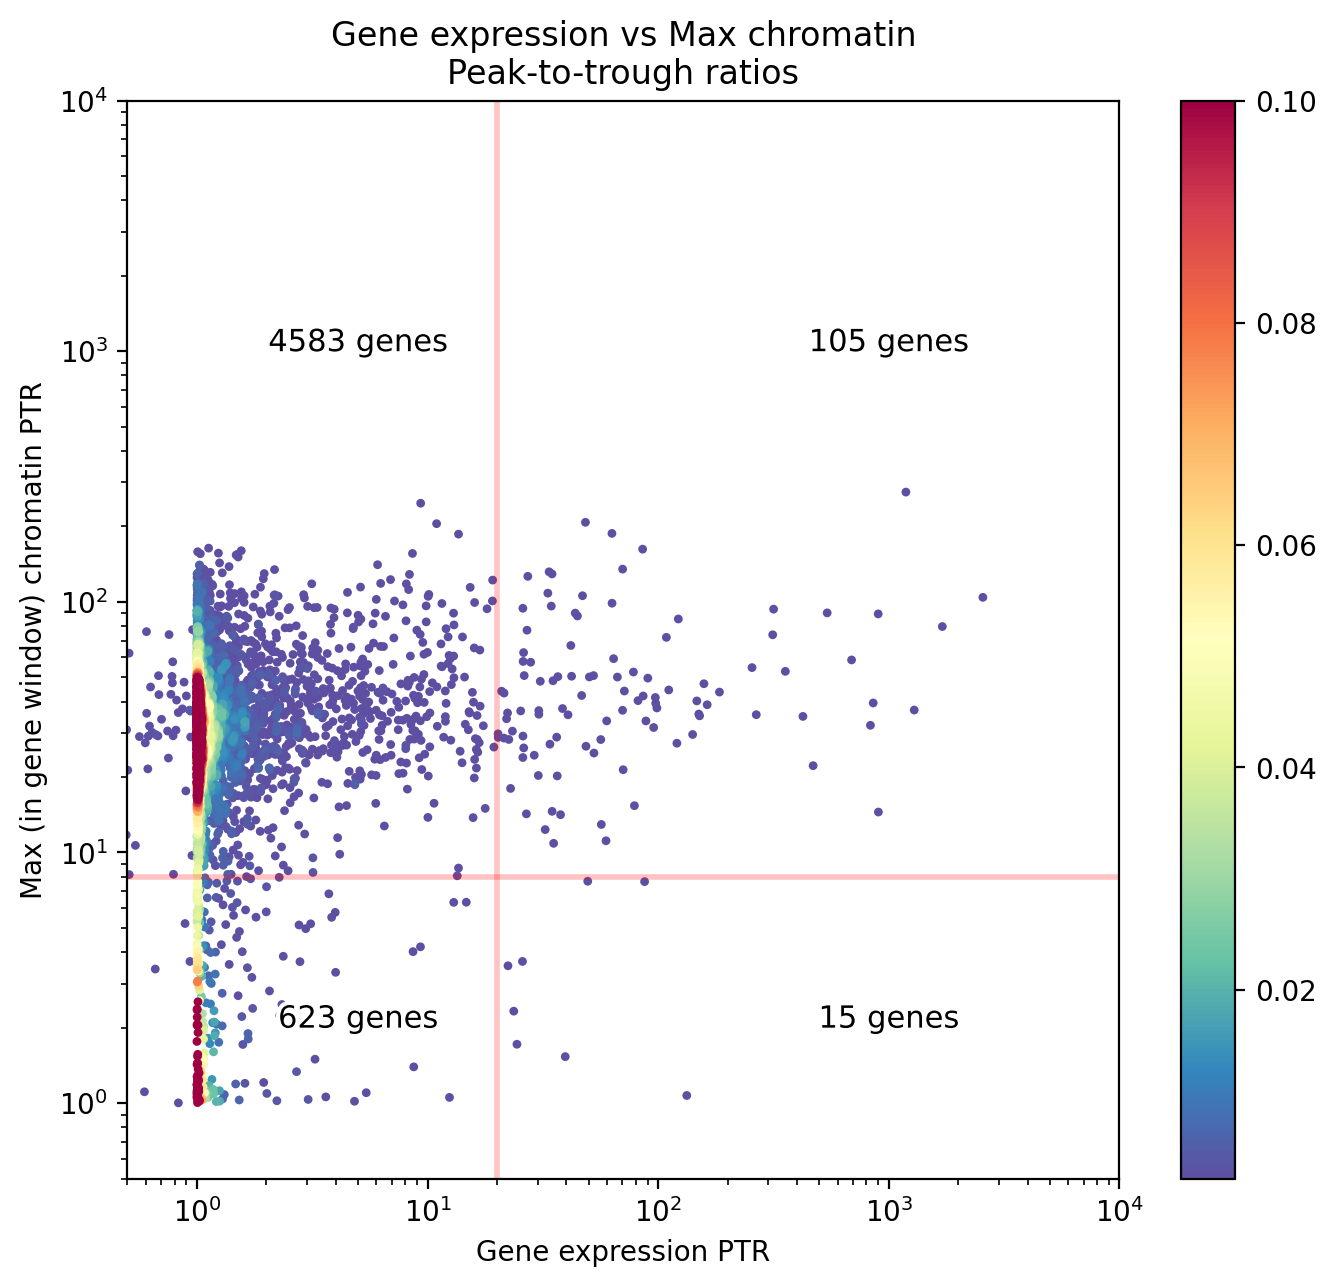

In [289]:
analysis.plot_chrom_ge_ptr_scatter()

In [190]:
# Write the combined gene expression and chromatin PTRs to disk
combined_save_df = analysis.combined_ptr_dfs.join(genes[['gene']])
combined_save_df.to_csv('output/gene_expression_vs_max_chrom_ptr.csv')
combined_save_df.head(2)

,ge_ptr,max_chrom_ptr,gene
orf_name,,,
YLR146C,1.0662,40.344424,SPE4
YLR056W,1.5543,27.493960,ERG3


In [228]:
# Realization: We want to show the story of deconvolving the chromatin compared to 
# non-deconvolved chromatin how much better is it?

# So let's load the g values and compute the PTR of them

from cc_src.peak_to_trough import get_chrom_g_ptr

CHROMATIN_DIR = 'output/deconvolve_chromatin_2023_12_15/'

import glob
import os
import numpy as np

# Then we need to sort this into a dataframe
genes = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv')\
    		.set_index('orf_name')

gene_max_g_ptrs = genes[['gene']].copy()

pattern = os.path.join(CHROMATIN_DIR, '*g_*')
files_with_ptr = glob.glob(pattern)

for filename in files_with_ptr:

    orf_name = filename.split('/')[-1].split('_')[-1].replace('.npy', '')
    gene_g_chrom = np.load(filename)
    g_ptr, g_ptr_max = get_chrom_g_ptr(gene_g_chrom)
    
    gene_max_g_ptrs.loc[orf_name, 'max_g_ptr'] = g_ptr_max


In [232]:
combined_with_g_ptrs_df = combined_save_df.join(gene_max_g_ptrs[['max_g_ptr']])
combined_with_g_ptrs_df

,ge_ptr,max_chrom_ptr,gene,max_g_ptr
orf_name,,,,
YLR146C,1.0662,40.344424,SPE4,2.135135
YLR056W,1.5543,27.493960,ERG3,1.971429
YHR107C,1.0134,22.305514,CDC12,2.306452
YPR078C,1.0919,0.000000,YPR078C,NaN
YAL043C,1.6516,NaN,PTA1,3.000000
...,...,...,...,...
YLR094C,1.1779,45.206277,GIS3,2.343750
YMR095C,1.5569,19.443617,SNO1,2.520000
YCR095W-A,4.8387,18.621375,YCR095W-A,2.095238


Text(0.5, 1.0, 'Comparison between original and\ndeconvolved chromatin peak-to-trough ratios')

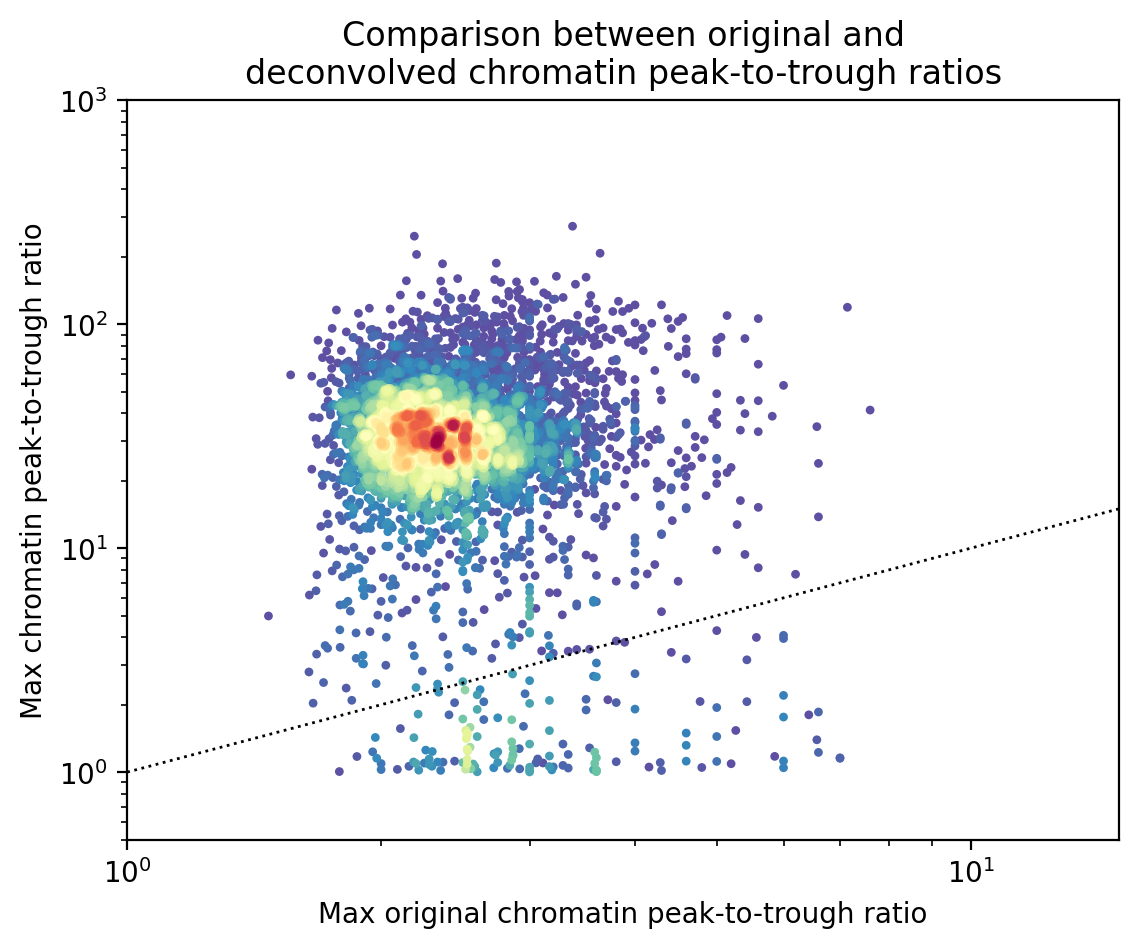

In [283]:
ax = plt.gca()

g_density_plotter = DensityScatterPlotter()
g_density_plotter.cmap='Spectral_r'
g_density_plotter.bw = (0.02, 1)

plt_data = combined_with_g_ptrs_df.dropna()
x, y = plt_data.max_g_ptr, plt_data.max_chrom_ptr

g_density_plotter.set_data(x, y)

g_density_plotter.plot_ax(ax)

ax.set_ylabel('Max chromatin peak-to-trough ratio')
ax.set_xlabel('Max original chromatin peak-to-trough ratio')

ax.set_yscale('log')
ax.set_xscale('log')
ax.plot([1, 300], [1, 300], c='black', lw=1, linestyle='dotted')
ax.set_ylim(5e-1, 1000)
ax.set_xlim(1, 15)
ax.set_title("Comparison between original and\ndeconvolved chromatin peak-to-trough ratios")
